<a href="https://colab.research.google.com/github/awrunpatel/django-dashub/blob/main/Seminar_7_Big_data_Text_Mining_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
get_ipython().system('pip install "dask[distributed]"')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00


In [4]:
from dask.distributed import Client, LocalCluster

# Start a small local cluster for distributed text processing
# This creates multiple workers so incoming text batches can be processed in parallel
cluster = LocalCluster(n_workers=2, threads_per_worker=2, dashboard_address=":8787")

# Connect the client to the cluster so all operations run on distributed workers
client = Client(cluster)

# Display cluster information for students to confirm the distributed environment is active
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:35629
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35309'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34065'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:41227 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:41227
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53222
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:45287 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:45287
INFO:distributed.core:Starting established connection to tcp://127

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35629,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41227,Total threads: 2
Dashboard: http://127.0.0.1:39415/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:35309,


In [5]:
import time
import requests

# This API (https://api.quotable.io/random) provides short, clean, single-sentence quotes.
# The text is varied, human-written, and ideal for teaching tokenisation, streaming behaviour,
# and later analysis tasks such as sentiment trends or pattern detection.

def fetch_text():
    url = "http://api.quotable.io/random"
    response = requests.get(url, timeout=5)
    data = response.json()
    return data["content"]

# Generator that yields micro-batches of real text
def text_stream(batch_size=5):
    while True:
        batch = [fetch_text() for _ in range(batch_size)]
        yield batch
        time.sleep(1)  # simulate real-time arrival

In [6]:
import dask.bag as db

# Function that takes a batch of text messages and distributes them across workers
# Each message becomes an item in a Dask Bag, enabling parallel tokenisation and analysis
def batch_to_bag(batch):
    return db.from_sequence(batch, npartitions=2)

In [7]:
import re

# Basic text cleaning: lowercase, remove punctuation, split into tokens
def clean_and_tokenise(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # keep only letters and spaces
    tokens = text.split()
    return tokens

# Apply cleaning and tokenisation to a distributed Dask Bag
# Each message is processed independently across workers
def process_bag(bag):
    return bag.map(clean_and_tokenise)

In [8]:
# Real-time loop: fetch a batch, distribute it, process it, and preview results
# This runs once for demonstration; in a real stream you would loop indefinitely

stream = text_stream(batch_size=5)

# Get one incoming micro-batch of real text
batch = next(stream)

print("Incoming text batch:")
for line in batch:
    print(" •", line)

# Convert batch to a distributed Dask Bag
bag = batch_to_bag(batch)

# Clean and tokenise in parallel across workers
tokens_bag = process_bag(bag)

# Compute to preview the processed output
tokens_preview = tokens_bag.compute()

print("\nTokenised output:")
for t in tokens_preview:
    print(" •", t)

Incoming text batch:
 • People are so constituted that everybody would rather undertake what they see others do, whether they have an aptitude for it or not.
 • It's important to know that words don't move mountains. Work, exacting work moves mountains.
 • A leader or a man of action in a crisis almost always acts subconsciously and then thinks of the reasons for his action.
 • It's supposed to be automatic, but actually you have to push this button.
 • We cannot be more sensitive to pleasure without being more sensitive to pain.

Tokenised output:
 • ['people', 'are', 'so', 'constituted', 'that', 'everybody', 'would', 'rather', 'undertake', 'what', 'they', 'see', 'others', 'do', 'whether', 'they', 'have', 'an', 'aptitude', 'for', 'it', 'or', 'not']
 • ['its', 'important', 'to', 'know', 'that', 'words', 'dont', 'move', 'mountains', 'work', 'exacting', 'work', 'moves', 'mountains']
 • ['a', 'leader', 'or', 'a', 'man', 'of', 'action', 'in', 'a', 'crisis', 'almost', 'always', 'acts', 'sub

In [9]:
info = client.scheduler_info()

print("Number of workers:", len(info["workers"]))
for wid, w in info["workers"].items():
    print(f"Worker {wid[:6]} | Threads: {w['nthreads']} | Memory: {w['memory_limit'] / 1e9:.2f} GB")

Number of workers: 2
Worker tcp:// | Threads: 2 | Memory: 6.80 GB
Worker tcp:// | Threads: 2 | Memory: 6.80 GB


In [10]:
from collections import Counter

# Count tokens within each message, then combine counts across the distributed batch
def count_words(tokens_bag):
    # Each list of tokens becomes a Counter
    per_message_counts = tokens_bag.map(lambda tokens: Counter(tokens))

    # Reduce all Counters into one combined Counter
    total_counts = per_message_counts.fold(lambda x, y: x + y)

    return total_counts

In [11]:
# Compute distributed word counts for the current batch
word_counts = count_words(tokens_bag).compute()

# Show the most common words in this micro‑batch
print("Top words in this batch:")
for word, count in word_counts.most_common(10):
    print(f" • {word}: {count}")

Top words in this batch:
 • to: 5
 • a: 3
 • that: 2
 • they: 2
 • have: 2
 • for: 2
 • or: 2
 • its: 2
 • mountains: 2
 • work: 2


In [12]:
# Running counter that keeps track of word frequencies across all processed batches
running_counts = Counter()

# Function that updates the running counter with the latest batch results
def update_running_counts(batch_counts):
    global running_counts
    running_counts.update(batch_counts)
    return running_counts

In [13]:
# Process several incoming batches to simulate a real streaming workflow
# Each batch is fetched, distributed, tokenised, counted, and merged into the running totals

for i in range(3):   # adjust this number to stream more batches
    print(f"\n--- Batch {i+1} ---")

    # Fetch the next micro-batch of real text
    batch = next(stream)

    print("Incoming text:")
    for line in batch:
        print(" •", line)

    # Distribute the batch across workers
    bag = batch_to_bag(batch)

    # Clean and tokenise in parallel
    tokens_bag = process_bag(bag)

    # Count words in this batch
    batch_counts = count_words(tokens_bag).compute()

    print("\nTop words in this batch:")
    for word, count in batch_counts.most_common(5):
        print(f" • {word}: {count}")

    # Update running totals
    updated = update_running_counts(batch_counts)

    print("\nRunning totals so far:")
    for word, count in updated.most_common(5):
        print(f" • {word}: {count}")


--- Batch 1 ---
Incoming text:
 • We read the world wrong and say that it deceives us.
 • Work for something because it is good, not just because it stands a chance to succeed.
 • When you are offended at any man's fault, turn to yourself and study your own failings. Then you will forget your anger.
 • True friendship is a plant of slow growth, and must undergo and withstand the shocks of adversity, before it is entitled to the appellation.
 • If there is no struggle, there is no progress.

Top words in this batch:
 • is: 5
 • and: 4
 • it: 4
 • the: 3
 • to: 3

Running totals so far:
 • is: 5
 • and: 4
 • it: 4
 • the: 3
 • to: 3

--- Batch 2 ---
Incoming text:
 • Do you want to know who you are? Don't ask. Act! Action will delineate and define you.
 • Just as a flower, which seems beautiful has color but no perfume, so are the fruitless words of a man who speaks them but does them not.
 • The most I can do for my friend is simply be his friend.
 • There is nothing impossible to him 

How Dask Processes Each Incoming Batch
Dask does not send the whole batch to every worker. Instead:
- A batch arrives as a normal Python list in the notebook.
- Dask splits the batch into partitions (small slices of the data).
- Each partition is sent to a different worker when computation starts.
- Workers only process their own slice, not the full batch.
- After processing, workers return partial results, and the scheduler combines them.
Key idea:
Workers never store or duplicate the full batch — they only handle the partition assigned to them



--- Batch 1 ---

--- Batch 2 ---

--- Batch 3 ---


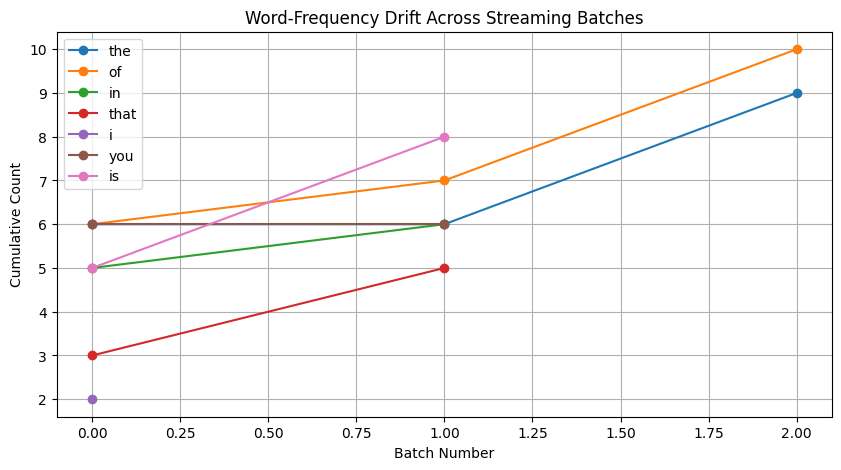

In [14]:
import matplotlib.pyplot as plt

# Track history of top words across batches
history = {}

# Reset running counts for a clean plot
running_counts = Counter()

for i in range(3):   # adjust number of batches
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Distribute and process
    bag = batch_to_bag(batch)
    tokens_bag = process_bag(bag)
    batch_counts = count_words(tokens_bag).compute()

    # Update running totals
    running_counts.update(batch_counts)

    # Track top words over time
    top_words = running_counts.most_common(5)
    for word, count in top_words:
        history.setdefault(word, []).append(count)

# Plot drift
plt.figure(figsize=(10, 5))
for word, counts in history.items():
    plt.plot(counts, marker='o', label=word)

plt.title("Word-Frequency Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Cumulative Count")
plt.legend()
plt.grid(True)
plt.show()


--- Batch 1 ---

--- Batch 2 ---

--- Batch 3 ---

--- Batch 4 ---

--- Batch 5 ---


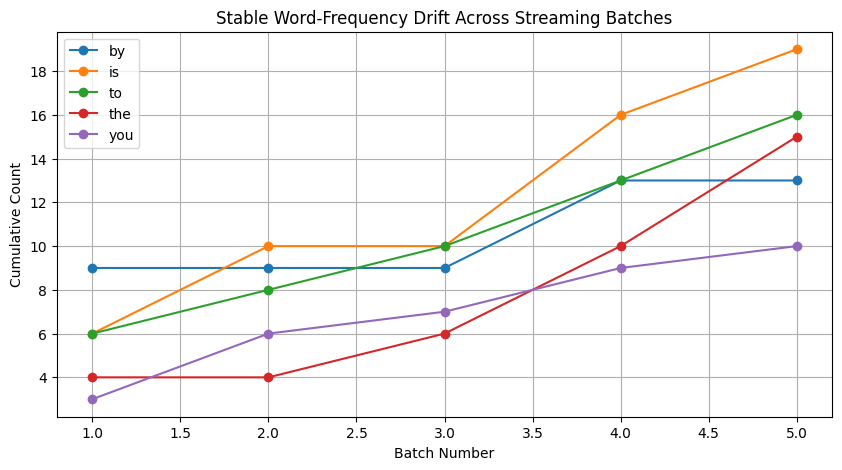

In [15]:

# Reset running counts and history
running_counts = Counter()
history = {}
num_batches = 5

for i in range(num_batches):
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Process batch
    bag = batch_to_bag(batch)
    tokens_bag = process_bag(bag)
    batch_counts = count_words(tokens_bag).compute()

    # Update running totals
    running_counts.update(batch_counts)

    # Select a fixed set of words to track (top words after this batch)
    if i == 0:
        tracked_words = [w for w, _ in running_counts.most_common(5)]

    # Record counts for tracked words (fill missing with zero)
    for word in tracked_words:
        history.setdefault(word, []).append(running_counts.get(word, 0))

# Plot stable drift
plt.figure(figsize=(10, 5))
for word, counts in history.items():
    plt.plot(range(1, num_batches + 1), counts, marker='o', label=word)

plt.title("Stable Word-Frequency Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Cumulative Count")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.5 MB/s eta 0:00:00



--- Batch 1 ---
Sentence-level sentiment:
 • Your vision will become clear only when you can look into your own heart. Who looks outside, dreams, who looks inside, awakes.  -->  0.888 (positive)
 • You can't choose up sides on a round world.  -->  0.000 (neutral)
 • Give me a lever long enough and a fulcrum on which to place it, and I shall move the world.  -->  0.000 (neutral)
 • You can tell whether a man is clever by his answers. You can tell whether a man is wise by his questions.  -->  0.727 (positive)
 • I do not believe in a fate that falls on men however they act; but I do believe in a fate that falls on them unless they act.  -->  0.000 (neutral)

Average sentiment: 0.323 (positive)

--- Batch 2 ---
Sentence-level sentiment:
 • Truth, and goodness, and beauty are but different faces of the same all.  -->  0.619 (positive)
 • I have realized that the past and future are real illusions, that they exist in the present, which is what there is and all there is.  -->  0.000 (neutra

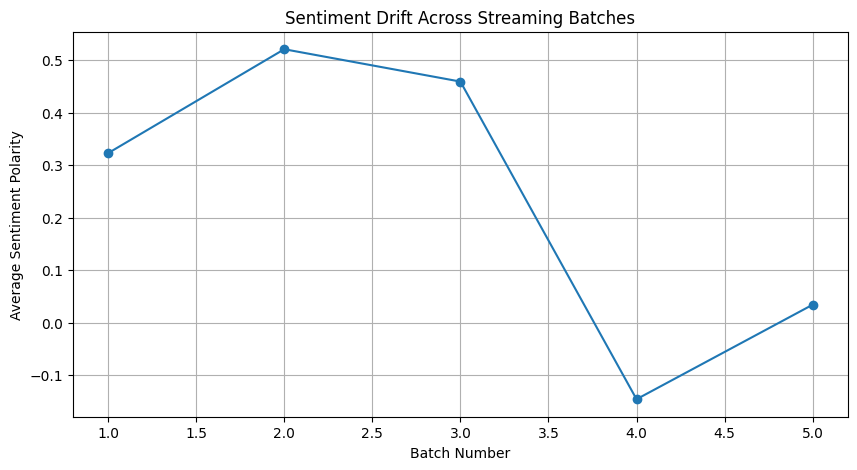

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# VADER is used here as a lightweight sentiment analysis tool.
# It provides a compound polarity score for each line of text (range -1 to +1),
# designed specifically for short, informal text such as quotes or social media.
# This makes it fast, dependency-light, and suitable for streaming demos
# where the focus is on the streaming pipeline rather than model complexity.

analyzer = SentimentIntensityAnalyzer()

def sentiment_label(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

def batch_sentiment(batch):
    scores = []
    for line in batch:
        polarity = analyzer.polarity_scores(line)["compound"]
        scores.append(polarity)
    return sum(scores) / len(scores) if scores else 0.0

# Track sentiment over time
sentiment_history = []
num_batches = 5

for i in range(num_batches):
    print(f"\n--- Batch {i+1} ---")

    batch = next(stream)

    # Show sentence-level sentiment for teaching clarity
    print("Sentence-level sentiment:")
    for line in batch:
        score = analyzer.polarity_scores(line)["compound"]
        label = sentiment_label(score)
        print(f" • {line}  -->  {score:.3f} ({label})")

    # Compute batch-level average sentiment
    avg_sent = batch_sentiment(batch)
    sentiment_history.append(avg_sent)

    print(f"\nAverage sentiment: {avg_sent:.3f} ({sentiment_label(avg_sent)})")

# Plot sentiment drift
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_batches + 1), sentiment_history, marker='o')
plt.title("Sentiment Drift Across Streaming Batches")
plt.xlabel("Batch Number")
plt.ylabel("Average Sentiment Polarity")
plt.grid(True)
plt.show()